# ==========================================================
# EXPLICACIÓN DEL ALGORITMO SIMULATED ANNEALING
# ==========================================================
#
# Simulated Annealing es una metaheurística inspirada en el
# proceso físico de enfriamiento de los metales. Su objetivo
# es encontrar soluciones de buena calidad evitando quedar
# atrapado en mínimos locales.
#
# El algoritmo comienza con una ruta aleatoria y genera
# pequeñas modificaciones intercambiando ciudades. Si la
# nueva ruta tiene un menor costo, se acepta inmediatamente.
# Si la nueva ruta es peor, aún puede ser aceptada con una
# cierta probabilidad controlada por la temperatura actual.
#
# Esta característica permite explorar regiones diferentes
# del espacio de búsqueda y escapar de soluciones locales
# que podrían impedir encontrar rutas más eficientes.
#
# PARÁMETROS UTILIZADOS:
#
# Iteraciones = 1000
# Representa la cantidad de intentos de mejora que realizará
# el algoritmo. En cada iteración se genera un vecino, se
# evalúa su costo y se decide si será aceptado o rechazado.
# Se eligieron 1000 iteraciones para lograr un equilibrio
# entre calidad de solución y tiempo de ejecución.
#
# Si se aumenta este valor:
# - Se exploran más soluciones.
# - Puede encontrarse una mejor ruta.
# - Aumenta el tiempo de ejecución.
#
# Si se disminuye:
# - El algoritmo termina más rápido.
# - Explora menos alternativas.
# - Puede obtener soluciones de menor calidad.
#
# Temperatura Inicial = 1000
# Controla la probabilidad de aceptar soluciones peores al
# comienzo de la búsqueda. Un valor alto permite una mayor
# exploración y facilita escapar de mínimos locales.
#
# Si se aumenta:
# - Se aceptan más soluciones peores.
# - Existe mayor exploración.
# - La convergencia puede ser más lenta.
#
# Si se disminuye:
# - El algoritmo se vuelve más conservador.
# - Explora menos regiones del problema.
# - Aumenta el riesgo de quedar atrapado en mínimos locales.
#
# Factor de Enfriamiento = 0.995
# Determina la velocidad con la que disminuye la temperatura.
# En cada iteración:
#
# Temperatura = Temperatura × 0.995
#
# Se eligió 0.995 porque permite una reducción gradual de la
# temperatura, manteniendo un equilibrio adecuado entre
# exploración inicial y refinamiento final.
#
# Si se aumenta (ejemplo 0.999):
# - La temperatura disminuye más lentamente.
# - El algoritmo explora durante más tiempo.
# - Aumenta el tiempo de ejecución.
#
# Si se disminuye (ejemplo 0.90):
# - La temperatura cae rápidamente.
# - El algoritmo se vuelve voraz antes de tiempo.
# - Puede quedar atrapado en mínimos locales.
#
# En resumen, Simulated Annealing utiliza una combinación de
# exploración y explotación. Al inicio acepta muchos cambios
# para recorrer distintas zonas del problema y, a medida que
# la temperatura disminuye, se concentra en perfeccionar las
# mejores rutas encontradas.
# ==========================================================

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math
import time

ciudades = np.array([

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)

])

n_ciudades = len(ciudades)

print("Cantidad de ciudades:", n_ciudades)

Cantidad de ciudades: 16


In [4]:
def distancia(a, b):
    return np.linalg.norm(a - b)

In [5]:
dist_matrix = np.array([
    [distancia(ciudades[i], ciudades[j]) for j in range(n_ciudades)]
    for i in range(n_ciudades)
])

In [6]:
def costo(ruta):
    return sum(dist_matrix[ruta[i]][ruta[i+1]] for i in range(len(ruta)-1)) + dist_matrix[ruta[-1]][ruta[0]]

In [7]:
def plot_ruta(ruta, titulo="Ruta"):
    r = np.array([ciudades[i] for i in ruta] + [ciudades[ruta[0]]])

    plt.figure()
    plt.plot(r[:,0], r[:,1], marker='o')
    plt.title(titulo)
    plt.show()

In [8]:
def generar_vecino(ruta):
    vecino = ruta[:]
    i, j = random.sample(range(n_ciudades), 2)
    vecino[i], vecino[j] = vecino[j], vecino[i]
    return vecino

In [9]:
def recorrido_simulado(iteraciones=1000, temperatura_inicial=1000, enfriamiento=0.995):
    actual = random.sample(range(n_ciudades), n_ciudades)
    mejor = actual[:]

    costo_actual = costo(actual)
    mejor_costo = costo_actual

    temperatura = temperatura_inicial

    for _ in range(iteraciones):
        vecino = generar_vecino(actual)
        costo_vecino = costo(vecino)

        delta = costo_vecino - costo_actual

        if delta < 0 or random.random() < math.exp(-delta / temperatura):
            actual = vecino
            costo_actual = costo_vecino

        if costo_actual < mejor_costo:
            mejor = actual[:]
            mejor_costo = costo_actual

        temperatura *= enfriamiento

    return mejor

===== SIMULATED ANNEALING =====

Ruta encontrada:
[10, 14, 4, 12, 2, 0, 1, 3, 6, 15, 5, 7, 13, 11, 8, 9]

Costo total:
309.89

Iteraciones:
1000

Temperatura inicial:
1000

Factor de enfriamiento:
0.995

Tiempo:
0.0158 segundos


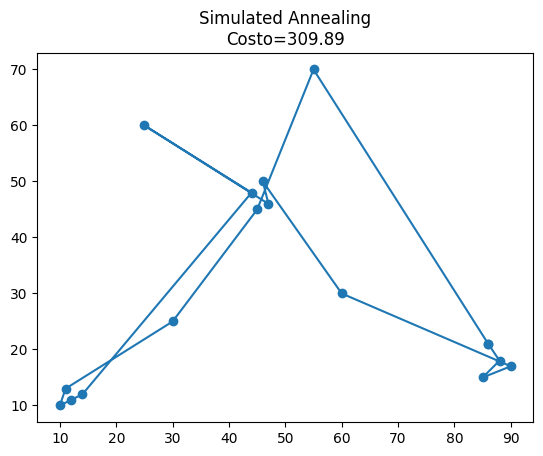

In [18]:
inicio = time.time()

ruta_sa = recorrido_simulado(
    iteraciones=1000,
    temperatura_inicial=1000,
    enfriamiento=0.995
)

fin = time.time()

tiempo_sa = fin - inicio

costo_sa = costo(ruta_sa)

print("===== SIMULATED ANNEALING =====\n")

print("Ruta encontrada:")
print(ruta_sa)

print("\nCosto total:")
print(round(costo_sa, 2))

print("\nIteraciones:")
print(1000)

print("\nTemperatura inicial:")
print(1000)

print("\nFactor de enfriamiento:")
print(0.995)

print("\nTiempo:")
print(round(tiempo_sa, 4), "segundos")

plot_ruta(
    ruta_sa,
    f"Simulated Annealing\nCosto={round(costo_sa,2)}"
)